Prophet Model

Train length: 1461
Test length : 320


09:40:56 - cmdstanpy - INFO - Chain [1] start processing
09:40:57 - cmdstanpy - INFO - Chain [1] done processing



--- METRIKEN (Prophet) ---
MSE          : 18698808.68
RMSE         : 4324.21
R²           : 0.4941
MAE          : 3177.64
Relative MSE : 0.6454
MAPE         : 27.87%


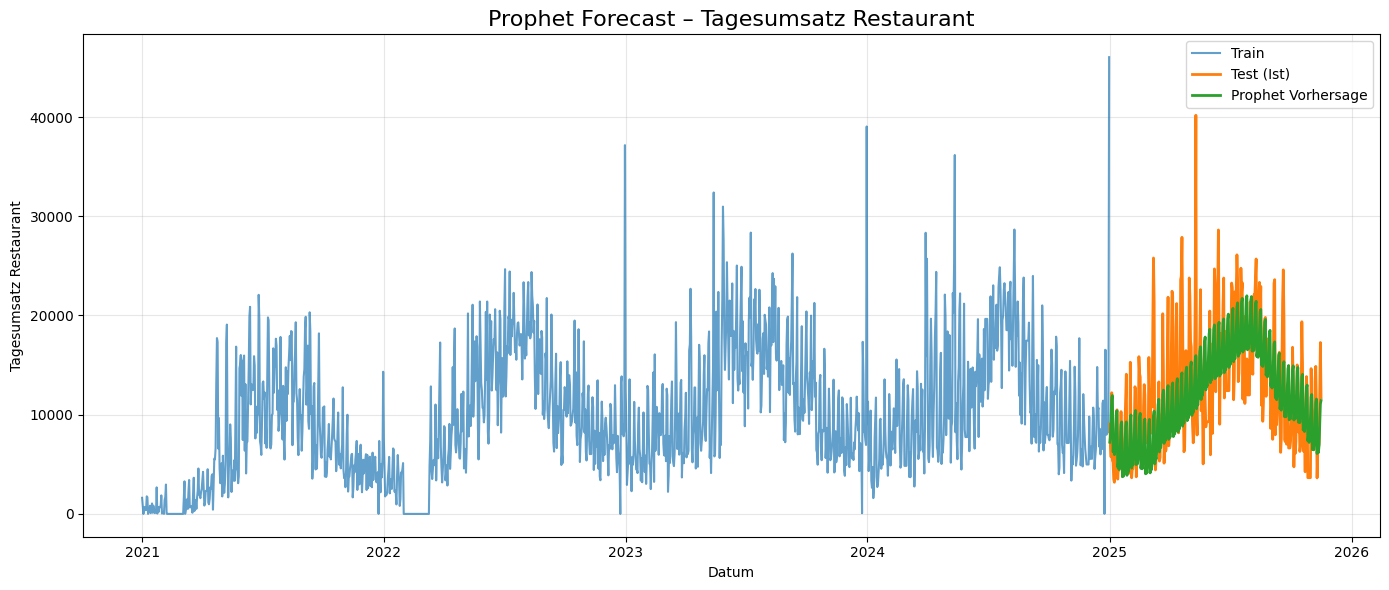

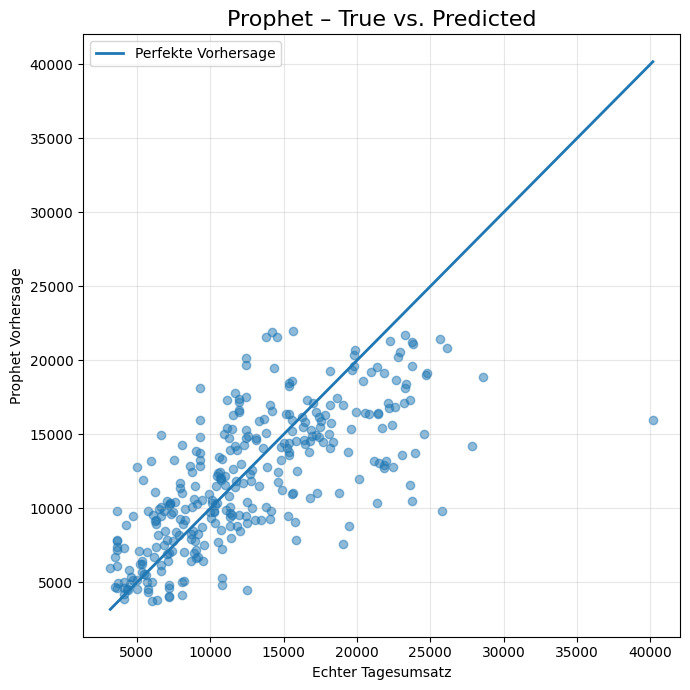

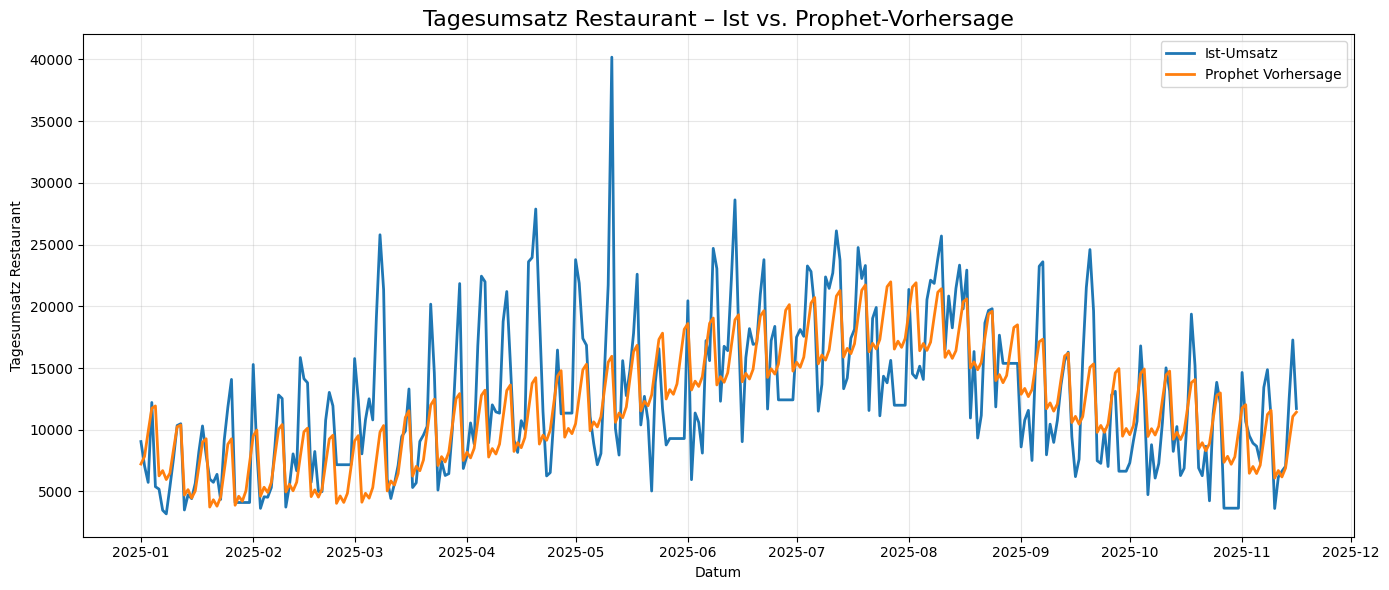

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1) Daten laden
df = pd.read_csv("data/dataset-merged-2.csv")
df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum")

# 2) Zeitreihe für Prophet vorbereiten: Spalten 'ds' (Date) und 'y' (Target)
# tägliche Frequenz + Lücken füllen, damit Prophet saubere Daten bekommt
ts = df.set_index("Datum")["Tagesumsatz Restaurant"].asfreq("D")
ts = ts.ffill().bfill()

df_p = ts.reset_index().rename(
    columns={"Datum": "ds", "Tagesumsatz Restaurant": "y"}
)

# 3) Train/Test-Split (zeitbasiert)
split_date = pd.Timestamp("2025-01-01")
train = df_p[df_p["ds"] < split_date]
test  = df_p[df_p["ds"] >= split_date]

print("Train length:", len(train))
print("Test length :", len(test))

# 4) Prophet-Modell definieren
m = Prophet(
    daily_seasonality=False,   # Tages-Saisonalität wäre bei stündlichen Daten relevant
    weekly_seasonality=True,   # Restaurant: klare Wochentagsmuster
    yearly_seasonality=True    # Jahresverlauf (Sommer/Winter, Ferien, etc.)
)

# (Optional: hier könnte man später zusätzliche Regressoren hinzufügen)

# 5) Modell fitten
m.fit(train)

# 6) Zukunfts-DataFrame erzeugen (Train + Test Zeitraum)
future = m.make_future_dataframe(
    periods=len(test), 
    freq="D"          # tägliche Frequenz
)

forecast_all = m.predict(future)

# Nur die Testperiode herausholen
forecast_test = forecast_all[forecast_all["ds"] >= split_date].copy()
forecast_test = forecast_test.set_index("ds").loc[test["ds"]].reset_index()

# 7) Metriken berechnen
y_true = test["y"].values
y_pred = forecast_test["yhat"].values

mse  = mean_squared_error(y_true, y_pred)
rmse = mse ** 0.5
r2   = r2_score(y_true, y_pred)
mae  = mean_absolute_error(y_true, y_pred)

# Naive Baseline: Vortag als Prognose
test_series = df_p.set_index("ds")["y"].loc[test["ds"]]
y_naive = test_series.shift(1).bfill().values

mse_naive = mean_squared_error(y_true, y_naive)
relative_MSE = mse / mse_naive

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = (y_true != 0)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_value = mape(y_true, y_pred)

print("\n--- METRIKEN (Prophet) ---")
print(f"MSE          : {mse:.2f}")
print(f"RMSE         : {rmse:.2f}")
print(f"R²           : {r2:.4f}")
print(f"MAE          : {mae:.2f}")
print(f"Relative MSE : {relative_MSE:.4f}")
print(f"MAPE         : {mape_value:.2f}%")

# 8) Zeitreihen-Plot: Train, Test, Prophet-Vorhersage
plt.figure(figsize=(14,6))
plt.plot(train["ds"], train["y"], label="Train", alpha=0.7)
plt.plot(test["ds"], test["y"], label="Test (Ist)", linewidth=2)
plt.plot(forecast_test["ds"], forecast_test["yhat"], label="Prophet Vorhersage", linewidth=2)

plt.title("Prophet Forecast – Tagesumsatz Restaurant", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 9) Scatter-Plot: True vs. Predicted
plt.figure(figsize=(7,7))
plt.scatter(y_true, y_pred, alpha=0.5)

min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         linewidth=2, label="Perfekte Vorhersage")

plt.title("Prophet – True vs. Predicted", fontsize=16)
plt.xlabel("Echter Tagesumsatz")
plt.ylabel("Prophet Vorhersage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 10) Kompakter Test-Plot: Ist vs. Prophet-Vorhersage
results_prophet = pd.DataFrame({
    "Datum": test["ds"],
    "Ist": y_true,
    "Vorhersage": y_pred
})

plt.figure(figsize=(14,6))
plt.plot(results_prophet["Datum"], results_prophet["Ist"],
         label="Ist-Umsatz", linewidth=2)
plt.plot(results_prophet["Datum"], results_prophet["Vorhersage"],
         label="Prophet Vorhersage", linewidth=2)

plt.title("Tagesumsatz Restaurant – Ist vs. Prophet-Vorhersage", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
